# Curriculum PPO — RugbyHRL

Train the agent progressively: easy tasks first (no enemies, ball close), advancing to harder stages (more enemies, faster, ball far) only when the agent masters the current one.

- **Curriculum stages** : each stage is a dict specifying env difficulty (num enemies, speed, ball placement)
- **Swappable reward functions** : change the reward signal per stage or mid-training without restarting
- **Automatic promotion** : advance to the next stage when win-rate exceeds a threshold for N consecutive evals


In [10]:
import sys, os
sys.path.append(os.path.abspath('..'))

import math, random, time
from copy import deepcopy
from dataclasses import dataclass, field

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.categorical import Categorical
import gymnasium as gym
from tensordict import TensorDict
import matplotlib.pyplot as plt

import src.env  

SEED = 444
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ENV_NAME = "RugbyHRLGame1-v0"
print(f"Using device: {DEVICE}")


Using device: cpu


## Curriculum Stage Definitions

Each stage is a dict describing the difficulty.  
`ball_mode` controls where the ball spawns: `"close"` (near agent), `"random"` (anywhere), `"far"` (opposite side).  
Add / remove / reorder stages freely — the training loop will advance through them automatically.


In [11]:
from src.game.config import GameConfig, EnemyConfig, PlayerConfig, BallConfig
from src.game.object import Vec2

MAP_W, MAP_H = 700, 500      

def _ball_pos(mode: str) -> Vec2:
    """Return a ball start position based on mode."""
    px, py = 350, 440            # default player start
    if mode == "close":
        return Vec2(px + random.randint(-40, 40), py - random.randint(30, 80))
    elif mode == "far":
        return Vec2(random.randint(100, 600), random.randint(40, 150))
    else:  
        return Vec2(random.randint(60, MAP_W - 60), random.randint(60, MAP_H - 60))

def make_cfg(stage: dict) -> GameConfig:
    """Build a GameConfig from a curriculum stage dict."""
    cfg = GameConfig()
    cfg.ball.start_pos = _ball_pos(stage.get("ball_mode", "random"))

    enemy_cfgs = []
    for i in range(stage.get("num_enemies", 0)):
        speed = stage.get("enemy_speed", 2.2)
        # spread enemies across the top half
        ex = 100 + i * (500 // max(stage.get("num_enemies", 1), 1))
        ey = random.randint(60, 220)
        enemy_cfgs.append(EnemyConfig(start_pos=Vec2(ex, ey), max_speed=speed))
    cfg.enemies = enemy_cfgs
    return cfg

CURRICULUM_STAGES = [
    {"label": "Stage 0 : no enemies, ball close",  "num_enemies": 0, "enemy_speed": 2.2, "ball_mode": "close"},
    {"label": "Stage 1 : no enemies, ball random", "num_enemies": 0, "enemy_speed": 2.2, "ball_mode": "random"},
    {"label": "Stage 2 : 1 slow enemy, ball close","num_enemies": 1, "enemy_speed": 1.5, "ball_mode": "close"},
    {"label": "Stage 3 : 1 enemy, ball random",    "num_enemies": 1, "enemy_speed": 2.2, "ball_mode": "random"},
    {"label": "Stage 4 : 2 enemies, ball random",  "num_enemies": 2, "enemy_speed": 2.2, "ball_mode": "random"},
    {"label": "Stage 5 : 3 enemies, ball far",     "num_enemies": 3, "enemy_speed": 2.5, "ball_mode": "far"},
    {"label": "Stage 6 : 5 enemies, ball far",     "num_enemies": 5, "enemy_speed": 2.8, "ball_mode": "far"},
]

for i, s in enumerate(CURRICULUM_STAGES):
    print(f"  [{i}] {s['label']}")


  [0] Stage 0 : no enemies, ball close
  [1] Stage 1 : no enemies, ball random
  [2] Stage 2 : 1 slow enemy, ball close
  [3] Stage 3 : 1 enemy, ball random
  [4] Stage 4 : 2 enemies, ball random
  [5] Stage 5 : 3 enemies, ball far
  [6] Stage 6 : 5 enemies, ball far


## Dynamic Reward Functions

Define multiple reward functions and swap them during training.  
Each function receives the `result` dict from the engine step and the env's internal state, and returns a `float`.


In [12]:
import math as _math

def reward_delta_only(result, game_map, cfg, state):
    """
    Only delta-based progress signals.  No absolute terms.
    win=+100, lose=-100, pickup=+5, survival=+0.01/step.
    """
    if result.get("won"):
        return +100.0
    if result.get("lost"):
        return -100.0

    p = game_map.player
    b = game_map.ball
    g = game_map.goal
    if p is None or b is None:
        return 0.0

    W  = float(cfg.map.width)
    H  = float(cfg.map.height)
    md = _math.sqrt(W**2 + H**2)
    r  = 0.01   # survival bonus

    if not p.has_ball:
        dist = _math.sqrt((p.pos.x - b.pos.x)**2 + (p.pos.y - b.pos.y)**2)
        prev = state.get("prev_dist_to_ball")
        if prev is not None:
            r += 0.5 * (prev - dist) / md
        state["prev_dist_to_ball"] = dist
        state["prev_dist_to_goal"] = None
    else:
        if not state.get("has_picked_up_ball"):
            r += 5.0
            state["has_picked_up_ball"] = True
        gcx = g.pos.x + g.width  / 2
        gcy = g.pos.y + g.height / 2
        dist = _math.sqrt((p.pos.x - gcx)**2 + (p.pos.y - gcy)**2)
        prev = state.get("prev_dist_to_goal")
        if prev is not None:
            r += 0.5 * (prev - dist) / md
        state["prev_dist_to_goal"] = dist
        state["prev_dist_to_ball"] = None
    return r


def reward_sparse(result, game_map, cfg, state):
    """
    Purely sparse: only win/lose signals.  Forces the agent to explore.
    Useful for early stages where task completion is easy enough.
    """
    if result.get("won"):
        return +1.0
    if result.get("lost"):
        return -1.0
    return 0.0


def reward_dense(result, game_map, cfg, state):
    """
    Dense shaping: delta progress + absolute distance penalty (mild).
    """
    if result.get("won"):
        return +100.0
    if result.get("lost"):
        return -100.0

    p = game_map.player
    b = game_map.ball
    g = game_map.goal
    if p is None or b is None:
        return 0.0

    W  = float(cfg.map.width)
    H  = float(cfg.map.height)
    md = _math.sqrt(W**2 + H**2)
    r  = 0.01

    if not p.has_ball:
        dist = _math.sqrt((p.pos.x - b.pos.x)**2 + (p.pos.y - b.pos.y)**2)
        r += 0.05 * (1.0 - dist / md)             # mild absolute pull
        prev = state.get("prev_dist_to_ball")
        if prev is not None:
            r += 0.5 * (prev - dist) / md
        state["prev_dist_to_ball"] = dist
        state["prev_dist_to_goal"] = None
    else:
        if not state.get("has_picked_up_ball"):
            r += 5.0
            state["has_picked_up_ball"] = True
        gcx = g.pos.x + g.width  / 2
        gcy = g.pos.y + g.height / 2
        dist = _math.sqrt((p.pos.x - gcx)**2 + (p.pos.y - gcy)**2)
        r += 0.05 * (1.0 - dist / md)
        prev = state.get("prev_dist_to_goal")
        if prev is not None:
            r += 0.5 * (prev - dist) / md
        state["prev_dist_to_goal"] = dist
        state["prev_dist_to_ball"] = None
    return r


# ── Reward registry & manager ───────────────────────────────────────────────────
REWARD_REGISTRY = {
    "delta_only": reward_delta_only,
    "sparse":     reward_sparse,
    "dense":      reward_dense,
}

STAGE_REWARD_MAP = {
    0: "sparse",       
    1: "delta_only",
    2: "delta_only",
    3: "delta_only",
    4: "delta_only",
    5: "dense",   
    6: "dense",
}

class RewardFunctionManager:
    """Holds the active reward function and lets you hot-swap it."""

    def __init__(self, initial: str = "delta_only"):
        self.current_name = initial
        self.fn = REWARD_REGISTRY[initial]

    def set(self, name: str):
        assert name in REWARD_REGISTRY, f"Unknown reward fn '{name}'. Available: {list(REWARD_REGISTRY)}"
        self.current_name = name
        self.fn = REWARD_REGISTRY[name]
        print(f"  [reward] switched to '{name}'")

    def set_for_stage(self, stage_idx: int):
        name = STAGE_REWARD_MAP.get(stage_idx, "delta_only")
        self.set(name)

    def __call__(self, result, game_map, cfg, state):
        return self.fn(result, game_map, cfg, state)

reward_manager = RewardFunctionManager("sparse")


## Curriculum Environment

`CurriculumEnv` is a single (non-vectorized) env that:
1. Builds a fresh `GameConfig` from the current stage on every `reset()`
2. Uses the `RewardFunctionManager` to compute the reward instead of the env's built-in one
3. Exposes `set_stage(idx)` so the training loop can advance difficulty

`make_curriculum_vec_envs` wraps N of them for parallel training.


In [ ]:
import gymnasium as gym
import numpy as np
import src.game.object as obj
import src.game.map    as map_module
from src.game.games.game1_engine import Game1Engine
from gymnasium import spaces
import pygame

MAX_ENEMIES = 5

class CurriculumEnv(gym.Env):
    """
    A single gymnasium env that rebuilds the game engine from a curriculum
    stage dict on every reset(), and uses an external RewardFunctionManager
    to compute rewards.
    """
    metadata = {"render_modes": ["human"], "render_fps": 60}

    def __init__(self, stage: dict, reward_manager: RewardFunctionManager,
                 render_mode=None):
        super().__init__()
        self.stage          = stage
        self.reward_manager = reward_manager
        self.render_mode    = render_mode

        obs_dim = 4 + 4 + 1 + 2 + 2 * MAX_ENEMIES
        self.observation_space = spaces.Box(-1.0, 1.0, shape=(obs_dim,), dtype=np.float32)
        self.action_space      = spaces.Discrete(6)

        self._engine    = None
        self._game_map  = None
        self._cfg       = None
        self._renderer  = None
        self._ep_state  = {}          # mutable dict passed to reward fn each step
        self._last_info = {}

    def set_stage(self, stage: dict):
        """Hot-swap the difficulty. Takes effect on the next reset()."""
        self.stage = stage

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._cfg      = make_cfg(self.stage)
        self._game_map = map_module.Map.from_config(self._cfg)
        self._engine   = Game1Engine(self._game_map, self._cfg)
        self._engine.save_initial_state()
        self._ep_state = {"prev_dist_to_ball": None,
                          "prev_dist_to_goal": None,
                          "has_picked_up_ball": False}
        self._last_info = {}
        return self._get_obs(), {}

    def step(self, action: int):
        assert self._engine is not None, "call reset() first"
        move, do_push = self._decode_action(action)
        result = self._engine.step({"move": move, "push": do_push, "throw": None})

        obs        = self._get_obs()
        reward     = self.reward_manager(result, self._game_map, self._cfg, self._ep_state)
        terminated = result["done"]
        truncated  = self._engine.step_count >= 300
        info       = {"won": result.get("won", False),
                      "lost": result.get("lost", False),
                      "has_ball": result.get("has_ball", False),
                      "step": result["step"]}
        self._last_info = {**info, "reward": reward}
        return obs, reward, terminated, truncated, info

    def render(self):
        if self.render_mode != "human":
            return
        if self._renderer is None:
            from src.renderer.renderer import Renderer
            self._renderer = Renderer(self._game_map, fps=60)
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                self.close()
        self._renderer.render(self._last_info)

    def close(self):
        if self._renderer is not None:
            self._renderer.quit()
            self._renderer = None

    def _get_obs(self):
        m   = self._game_map
        cfg = self._cfg
        W, H = float(cfg.map.width), float(cfg.map.height)

        def nx(x): return 2.0 * x / W - 1.0
        def ny(y): return 2.0 * y / H - 1.0
        def nvx(v): return np.clip(v / cfg.player.max_speed, -1.0, 1.0)
        def nvy(v): return np.clip(v / cfg.player.max_speed, -1.0, 1.0)

        p, b, g = m.player, m.ball, m.goal
        px  = nx(p.pos.x)        if p else 0.0
        py  = ny(p.pos.y)        if p else 0.0
        pvx = nvx(p.velocity.x)  if p else 0.0
        pvy = nvy(p.velocity.y)  if p else 0.0
        bx  = nx(b.pos.x)        if b else 0.0
        by  = ny(b.pos.y)        if b else 0.0
        bvx = np.clip(b.velocity.x / 20.0, -1.0, 1.0) if b else 0.0
        bvy = np.clip(b.velocity.y / 20.0, -1.0, 1.0) if b else 0.0
        has_ball = 1.0 if (p and p.has_ball) else 0.0
        gcx = nx(g.pos.x + g.width  / 2)
        gcy = ny(g.pos.y + g.height / 2)

        enemy_obs = []
        for i in range(MAX_ENEMIES):
            if i < len(m.enemies):
                e = m.enemies[i]
                enemy_obs += [nx(e.pos.x), ny(e.pos.y)]
            else:
                enemy_obs += [0.0, 0.0]

        return np.array([px, py, pvx, pvy, bx, by, bvx, bvy,
                         has_ball, gcx, gcy] + enemy_obs, dtype=np.float32)

    @staticmethod
    def _decode_action(action: int):
        _MOVES = {0:(0,0),1:(0,-1),2:(0,1),3:(-1,0),4:(1,0),5:(0,0)}
        dx, dy  = _MOVES.get(int(action), (0,0))
        do_push = (int(action) == 5)
        return obj.Vec2(float(dx), float(dy)), do_push


def make_curriculum_vec_envs(stage: dict, reward_manager: RewardFunctionManager,
                              num_envs: int = 10):
    """Create a SyncVectorEnv of CurriculumEnv instances for a given stage."""
    fns = [lambda s=stage, rm=reward_manager: CurriculumEnv(s, rm) for _ in range(num_envs)]
    return gym.vector.SyncVectorEnv(fns)

# Quick smoke-test
_test_env = CurriculumEnv(CURRICULUM_STAGES[0], reward_manager)
obs, _ = _test_env.reset()
print(f"obs shape: {obs.shape}  |  action space: {_test_env.action_space}")
_test_env.close()
del _test_env


obs shape: (21,)  |  action space: Discrete(6)


## Agent, Rollout Collector & PPO Update

Identical to `classic_ppo` — reused here without modification.


In [14]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class Agent(nn.Module):
    def __init__(self, obs_dim: int, n_actions: int):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)), nn.Tanh(),
            layer_init(nn.Linear(64, 64)),      nn.Tanh(),
            layer_init(nn.Linear(64, 1), std=1.0),
        )
        self.actor = nn.Sequential(
            layer_init(nn.Linear(obs_dim, 64)), nn.Tanh(),
            layer_init(nn.Linear(64, 64)),      nn.Tanh(),
            layer_init(nn.Linear(64, n_actions), std=1.0),
        )

    def save(self, path): torch.save(self.state_dict(), path)
    def load(self, path): self.load_state_dict(torch.load(path, weights_only=True))
    def get_critic_value(self, x): return self.critic(x)
    def get_actor_values(self, x, action=None):
        probs = torch.distributions.Categorical(logits=self.actor(x))
        if action is None: action = probs.sample()
        return action, probs.log_prob(action), probs.entropy()

class CurriculumRolloutCollector:
    def __init__(self, agent, envs, num_steps, device, eval_env=None):
        self.agent = agent
        self.envs  = envs
        self.num_envs = envs.num_envs
        self.num_steps = num_steps
        self.device    = device
        self.eval_env  = eval_env

        self.obs_shape    = envs.single_observation_space.shape
        self.action_shape = envs.single_action_space.shape
        self._buf_shape   = (num_steps, self.num_envs)

        obs, _ = envs.reset()
        self.next_obs  = torch.tensor(obs, dtype=torch.float32, device=device)
        self.next_done = torch.zeros(self.num_envs, device=device)

    def reset_envs(self):
        """Call after advancing the curriculum stage to resync obs."""
        obs, _ = self.envs.reset()
        self.next_obs  = torch.tensor(obs, dtype=torch.float32, device=self.device)
        self.next_done = torch.zeros(self.num_envs, device=self.device)

    def get_next_rollout(self):
        buf = TensorDict({
            "obs":          torch.zeros(self._buf_shape + self.obs_shape,    device=self.device),
            "actions":      torch.zeros(self._buf_shape + self.action_shape, device=self.device),
            "log_probs":    torch.zeros(self._buf_shape,                     device=self.device),
            "rewards":      torch.zeros(self._buf_shape,                     device=self.device),
            "dones":        torch.zeros(self._buf_shape,                     device=self.device),
            "critic_values":torch.zeros(self._buf_shape,                     device=self.device),
        })
        next_obs, next_done = self.next_obs, self.next_done

        for t in range(self.num_steps):
            buf["obs"][t]   = next_obs
            buf["dones"][t] = next_done
            with torch.no_grad():
                action, log_prob, _ = self.agent.get_actor_values(next_obs)
                critic_val          = self.agent.get_critic_value(next_obs)
            buf["actions"][t]       = action
            buf["log_probs"][t]     = log_prob
            buf["critic_values"][t] = critic_val.flatten()

            next_obs_np, reward, term, trunc, _ = self.envs.step(action.cpu().numpy())
            reward    = torch.tensor(reward, dtype=torch.float32, device=self.device)
            next_done_np = np.logical_or(term, trunc)
            buf["rewards"][t] = reward
            next_obs  = torch.tensor(next_obs_np, dtype=torch.float32, device=self.device)
            next_done = torch.tensor(next_done_np, dtype=torch.float32, device=self.device)

        buf["next_obs"]  = next_obs
        buf["next_done"] = next_done
        with torch.no_grad():
            buf["next_value"] = self.agent.get_critic_value(next_obs).reshape(1, -1)
        self.next_obs, self.next_done = next_obs, next_done
        return buf

    def run_eval(self, num_episodes: int = 5):
        assert self.eval_env is not None
        final_rewards, wins = [], []
        for _ in range(num_episodes):
            obs, _ = self.eval_env.reset()
            obs_t  = torch.tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
            done, ep_r = False, 0.0
            last_info = {}
            while not done:
                with torch.no_grad():
                    action, _, _ = self.agent.get_actor_values(obs_t)
                obs_np, r, term, trunc, last_info = self.eval_env.step(action.squeeze().item())
                done  = term or trunc
                ep_r += r
                obs_t = torch.tensor(obs_np, dtype=torch.float32, device=self.device).unsqueeze(0)
            final_rewards.append(ep_r)
            wins.append(float(last_info.get("won", False)))
        return {"avg_reward": np.mean(final_rewards),
                "win_rate":   np.mean(wins),
                "rewards":    final_rewards}

def compute_gae(buf, device, gamma=0.99, gae_lambda=0.95):
    rewards, dones = buf["rewards"], buf["dones"]
    critic_values  = buf["critic_values"]
    next_done      = buf["next_done"]
    last_val       = buf["next_value"]
    T = len(rewards)

    advantages = torch.zeros_like(rewards)
    last_gae   = 0
    with torch.no_grad():
        for t in reversed(range(T)):
            if t == T - 1:
                nxt_nt = 1.0 - next_done
                nxt_v  = last_val
            else:
                nxt_nt = 1.0 - dones[t + 1]
                nxt_v  = critic_values[t + 1]
            delta   = rewards[t] + gamma * nxt_v * nxt_nt - critic_values[t]
            last_gae = delta + gamma * gae_lambda * nxt_nt * last_gae
            advantages[t] = last_gae
    buf["advantages"] = advantages
    buf["returns"]    = advantages + critic_values
    return buf



def ppo_update(agent, optimizer, buf, batch_size, minibatch_size,
               obs_shape, action_shape,
               clip_coef=0.2, ent_coef=0.05, vf_coef=0.5,
               update_epochs=4, max_grad_norm=0.5):
    b_obs   = buf["obs"].reshape((-1,) + tuple(obs_shape))
    b_lp    = buf["log_probs"].reshape(-1)
    b_acts  = buf["actions"].reshape((-1,) + tuple(action_shape))
    b_adv   = buf["advantages"].reshape(-1)
    b_ret   = buf["returns"].reshape(-1)
    inds    = np.arange(batch_size)

    for _ in range(update_epochs):
        np.random.shuffle(inds)
        for start in range(0, batch_size, minibatch_size):
            mb = inds[start:start + minibatch_size]
            _, new_lp, entropy = agent.get_actor_values(b_obs[mb], action=b_acts[mb])
            new_v = agent.get_critic_value(b_obs[mb]).view(-1)

            ratio = (new_lp - b_lp[mb]).exp()
            adv   = b_adv[mb]
            adv   = (adv - adv.mean()) / (adv.std() + 1e-8)

            pg = torch.max(-adv * ratio,
                           -adv * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)).mean()
            vl = 0.5 * ((new_v - b_ret[mb]) ** 2).mean()
            loss = pg - ent_coef * entropy.mean() + vf_coef * vl

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
            optimizer.step()



Agent, rollout collector, GAE and PPO update defined.


## Curriculum Manager

Tracks win-rate per stage and decides when to advance.  
Promotion happens when `win_rate >= promote_threshold` for `promote_n_evals` consecutive evaluations.


In [ ]:
class CurriculumManager:
    """
    Tracks eval win-rates and promotes the agent to the next stage
    when it has mastered the current one.

    Parameters
    ----------
    stages            : list of stage dicts
    promote_threshold : win-rate required to advance (0–1)
    promote_n_evals   : how many consecutive evals above threshold to trigger advance
    """

    def __init__(self, stages: list, promote_threshold: float = 0.80,
                 promote_n_evals: int = 3):
        self.stages             = stages
        self.promote_threshold  = promote_threshold
        self.promote_n_evals    = promote_n_evals
        self.stage_idx          = 0
        self._consecutive_good  = 0   # evals in a row above threshold
        self.transition_iters   = []  # iteration numbers where stage changed

    @property
    def current_stage(self) -> dict:
        return self.stages[self.stage_idx]

    @property
    def at_final_stage(self) -> bool:
        return self.stage_idx >= len(self.stages) - 1

    def record_eval(self, win_rate: float, iteration: int) -> bool:
        """
        Feed the latest eval win-rate.
        Returns True if the stage advanced this call.
        """
        if self.at_final_stage:
            return False

        if win_rate >= self.promote_threshold:
            self._consecutive_good += 1
        else:
            self._consecutive_good = 0

        if self._consecutive_good >= self.promote_n_evals:
            self.stage_idx += 1
            self._consecutive_good = 0
            self.transition_iters.append(iteration)
            print(f"\n  ⬆  Curriculum advanced to stage {self.stage_idx}: "
                  f"{self.current_stage['label']}")
            return True
        return False

    def progress_str(self) -> str:
        return (f"stage {self.stage_idx}/{len(self.stages)-1} "
                f"[{self.current_stage['label']}] "
                f"streak={self._consecutive_good}/{self.promote_n_evals}")


curriculum_manager = CurriculumManager(
    stages=CURRICULUM_STAGES,
    promote_threshold=0.80,   # promote when win-rate ≥ 80 %
    promote_n_evals=4,        
)
print(f"CurriculumManager ready.  Starting at: {curriculum_manager.current_stage['label']}")


CurriculumManager ready.  Starting at: Stage 0 : no enemies, ball close


## Initialize Agent, Envs & Hyperparameters


In [16]:
# ── Hyperparameters ─────────────────────────────────────────────────────────────
NUM_ENVS              = 10
NUM_STEPS_PER_ROLLOUT = 300
MINIBATCH_SIZE        = 256
UPDATE_EPOCHS         = 4
LEARNING_RATE         = 2.5e-4
NUM_ITERATIONS        = 1000   
EVAL_EVERY            = 50       
EVAL_EPISODES         = 8  
CHECKPOINT_DIR        = "./checkpoints_curriculum"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

train_envs = make_curriculum_vec_envs(
    CURRICULUM_STAGES[0], reward_manager, num_envs=NUM_ENVS
)

eval_env = CurriculumEnv(CURRICULUM_STAGES[0], reward_manager)

OBS_DIM   = train_envs.single_observation_space.shape[0]
N_ACTIONS = train_envs.single_action_space.n
agent     = Agent(OBS_DIM, N_ACTIONS).to(DEVICE)
optimizer = optim.Adam(agent.parameters(), lr=LEARNING_RATE, eps=1e-5)

collector = CurriculumRolloutCollector(
    agent=agent, envs=train_envs,
    num_steps=NUM_STEPS_PER_ROLLOUT,
    device=DEVICE, eval_env=eval_env,
)

print(f"Agent params: {sum(p.numel() for p in agent.parameters()):,}")
print(f"obs_dim={OBS_DIM}  n_actions={N_ACTIONS}  num_envs={NUM_ENVS}")


Agent params: 11,591
obs_dim=21  n_actions=6  num_envs=10


## Curriculum Training Loop

The loop:
1. Collects a rollout, computes GAE, runs a PPO update
2. Every `EVAL_EVERY` iterations: runs eval, feeds win-rate to `CurriculumManager`
3. If `CurriculumManager` says advance → rebuilds envs for the new stage, swaps reward fn, resets collector

> **Tip:** You can edit `reward_manager.set("dense")` in a new cell and run it while training is paused — it will take effect on the next rollout.


In [17]:
import time

log_rewards    = [] 
log_win_rates  = [] 
log_stages     = [] 
log_entropies  = []

elapsed_steps = 0
start_time    = time.time()

for iteration in range(NUM_ITERATIONS):
    agent.train()

    buf = collector.get_next_rollout()
    buf = compute_gae(buf, DEVICE)
    ppo_update(
        agent, optimizer, buf,
        batch_size=NUM_ENVS * NUM_STEPS_PER_ROLLOUT,
        minibatch_size=MINIBATCH_SIZE,
        obs_shape=train_envs.single_observation_space.shape,
        action_shape=train_envs.single_action_space.shape,
        update_epochs=UPDATE_EPOCHS,
    )
    elapsed_steps += NUM_ENVS * NUM_STEPS_PER_ROLLOUT

    if iteration % EVAL_EVERY == 0 or iteration == NUM_ITERATIONS - 1:
        agent.eval()
        with torch.no_grad():
            stats = collector.run_eval(num_episodes=EVAL_EPISODES)
        agent.train()

        avg_r    = stats["avg_reward"]
        win_rate = stats["win_rate"]
        log_rewards.append(avg_r)
        log_win_rates.append(win_rate)
        log_stages.append(curriculum_manager.stage_idx)

        ckpt = os.path.join(CHECKPOINT_DIR,
                            f"stage{curriculum_manager.stage_idx}_iter{iteration}.pth")
        agent.save(ckpt)

        elapsed = time.time() - start_time
        print(f"\riter {iteration:5d}/{NUM_ITERATIONS} | "
              f"steps {elapsed_steps:8,} | "
              f"avg_r {avg_r:7.2f} | win {win_rate:.0%} | "
              f"{curriculum_manager.progress_str()} | "
              f"t {elapsed:.0f}s        ")

        advanced = curriculum_manager.record_eval(win_rate, iteration)
        if advanced:
            new_stage = curriculum_manager.current_stage
            train_envs.close()
            train_envs = make_curriculum_vec_envs(new_stage, reward_manager, NUM_ENVS)
            collector.envs = train_envs
            collector.reset_envs()
            eval_env.close()
            eval_env = CurriculumEnv(new_stage, reward_manager)
            collector.eval_env = eval_env
            reward_manager.set_for_stage(curriculum_manager.stage_idx)

    else:
        print(f"\r  iter {iteration}/{NUM_ITERATIONS} | "
              f"{curriculum_manager.progress_str()}", end="", flush=True)

# ── Final save ──────────────────────────────────────────────────────────────────
agent.save(os.path.join(CHECKPOINT_DIR, "!final_model.pth"))
train_envs.close()
eval_env.close()
print("\nTraining complete.")


iter     0/1000 | steps    3,000 | avg_r    0.00 | win 0% | stage 0/6 [Stage 0 : no enemies, ball close] streak=0/3 | t 2s        
iter    50/1000 | steps  153,000 | avg_r    0.00 | win 0% | stage 0/6 [Stage 0 : no enemies, ball close] streak=0/3 | t 24s        
iter   100/1000 | steps  303,000 | avg_r    0.12 | win 12% | stage 0/6 [Stage 0 : no enemies, ball close] streak=0/3 | t 46s        
iter   150/1000 | steps  453,000 | avg_r    0.88 | win 88% | stage 0/6 [Stage 0 : no enemies, ball close] streak=0/3 | t 68s        
iter   200/1000 | steps  603,000 | avg_r    1.00 | win 100% | stage 0/6 [Stage 0 : no enemies, ball close] streak=1/3 | t 90s        
iter   250/1000 | steps  753,000 | avg_r    1.00 | win 100% | stage 0/6 [Stage 0 : no enemies, ball close] streak=2/3 | t 112s        

  ⬆  Curriculum advanced to stage 1: Stage 1 : no enemies, ball random
  [reward] switched to 'delta_only'
iter   300/1000 | steps  903,000 | avg_r   16.20 | win 12% | stage 1/6 [Stage 1 : no enemies, 

## Hot-swap Reward Function (run anytime during training)

Run any of the cells below to change the reward function on the fly.  
The change takes effect at the start of the next rollout — no need to restart training.


In [18]:

reward_manager.set("delta_only")


  [reward] switched to 'delta_only'


## Training Metrics Visualization


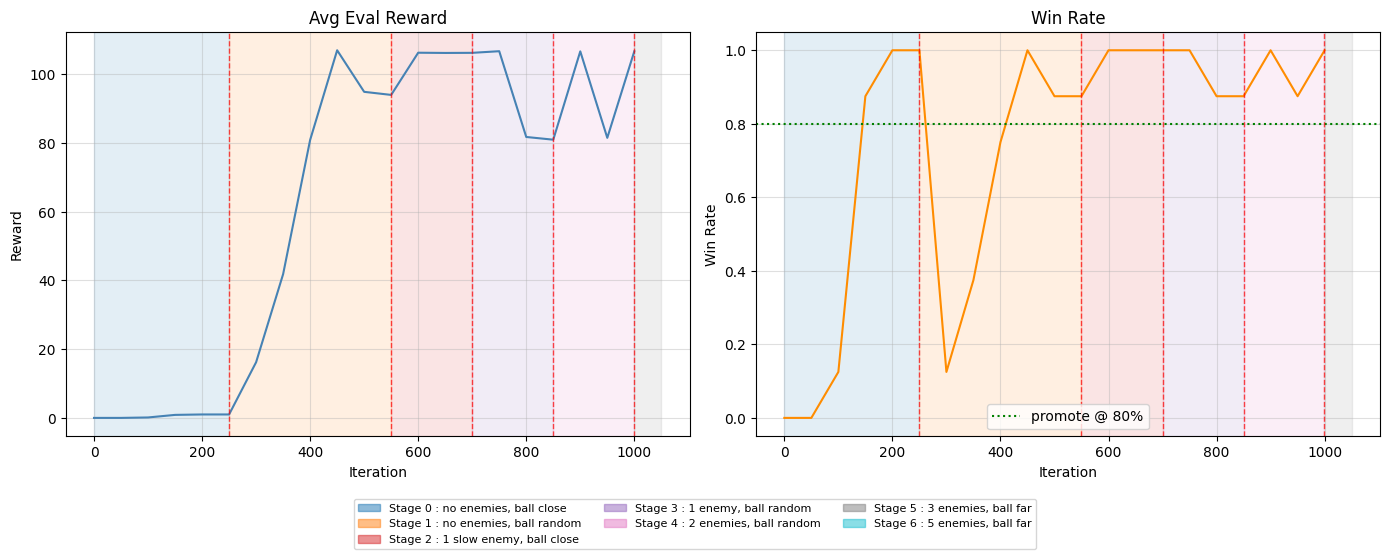

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

eval_iters = list(range(0, len(log_rewards) * EVAL_EVERY, EVAL_EVERY))

stage_colors = plt.cm.tab10(np.linspace(0, 0.9, len(CURRICULUM_STAGES)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

def shade_stages(ax, log_stages, eval_iters, stage_colors):
    boundaries = [0] + curriculum_manager.transition_iters + [eval_iters[-1] + EVAL_EVERY]
    si = 0
    for i in range(len(boundaries) - 1):
        color = stage_colors[min(si, len(stage_colors) - 1)]
        ax.axvspan(boundaries[i], boundaries[i + 1], alpha=0.12, color=color)
        si = min(si + 1, len(CURRICULUM_STAGES) - 1)

shade_stages(ax1, log_stages, eval_iters, stage_colors)
shade_stages(ax2, log_stages, eval_iters, stage_colors)

ax1.plot(eval_iters, log_rewards, color="steelblue", linewidth=1.5)
for t in curriculum_manager.transition_iters:
    ax1.axvline(t, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax1.set_title("Avg Eval Reward")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Reward")
ax1.grid(True, alpha=0.4)

# ── Plot win rate ───────────────────────────────────────────────────────────────
ax2.plot(eval_iters, log_win_rates, color="darkorange", linewidth=1.5)
ax2.axhline(curriculum_manager.promote_threshold, color="green", linestyle=":",
            linewidth=1.5, label=f"promote @ {curriculum_manager.promote_threshold:.0%}")
for t in curriculum_manager.transition_iters:
    ax2.axvline(t, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax2.set_title("Win Rate")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Win Rate")
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, alpha=0.4)
ax2.legend()

# ── Stage legend ────────────────────────────────────────────────────────────────
patches = [mpatches.Patch(color=stage_colors[i], alpha=0.5, label=s["label"])
           for i, s in enumerate(CURRICULUM_STAGES)]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=8,
           bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.show()


## Watch a Checkpoint Play

Load any saved checkpoint and watch the agent play.  
Set `WATCH_STAGE` and `WATCH_ITER` to match the checkpoint filename (`stage{WATCH_STAGE}_iter{WATCH_ITER}.pth`).


In [21]:
import pygame

WATCH_STAGE = 0          # ← stage index used when checkpoint was saved
WATCH_ITER  = 0          # ← iteration number in the filename
NUM_EPISODES = 3
MAX_STEPS    = 2_000
FPS          = 30

ckpt_path = os.path.join(CHECKPOINT_DIR, f"stage{WATCH_STAGE}_iter{WATCH_ITER}.pth")
# or load the final model:
# ckpt_path = os.path.join(CHECKPOINT_DIR, "!final_model.pth")

watch_agent = Agent(OBS_DIM, N_ACTIONS).to(DEVICE)
watch_agent.load(ckpt_path)
watch_agent.eval()

# Build the env matching the checkpoint stage
watch_stage = CURRICULUM_STAGES[WATCH_STAGE]
watch_env   = CurriculumEnv(watch_stage, reward_manager, render_mode="human")

watch_env.reset()
watch_env.render()

clock = pygame.time.Clock()

for ep in range(NUM_EPISODES):
    obs, _ = watch_env.reset()
    obs_t  = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    done, total_r, step = False, 0.0, 0

    watch_env.render()

    while not done and step < MAX_STEPS:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                done = True
                break
        if done:
            break
        with torch.no_grad():
            action, _, _ = watch_agent.get_actor_values(obs_t)
        obs, r, term, trunc, info = watch_env.step(action.squeeze().item())
        watch_env.render()
        obs_t   = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        total_r += r
        done     = term or trunc
        step    += 1
        clock.tick(FPS)

    print(f"Episode {ep+1}/{NUM_EPISODES} — steps: {step}  "
          f"reward: {total_r:.2f}  won: {info.get('won', False)}")

watch_env.close()
print("Done watching.")


Episode 1/3 — steps: 98  reward: 0.86  won: False
Episode 2/3 — steps: 28  reward: 0.24  won: False
Episode 3/3 — steps: 16  reward: 0.13  won: False
Done watching.
